In [2]:
import numpy as numpy
import pandas as pd


In [3]:
movies=pd.read_csv("movies.csv")
movies

,MovieID,Title,Genre,ReleaseYear,Director,Language,Duration_min,IMDB_Rating,Votes,BoxOffice_Million_USD
0,M0072,The Eternal Signal,Sci-Fi,2009,Anna Johnson,Urdu,180,5.7,15685,26.1
1,M0005,The Secret Legacy,Sci-Fi,2024,Emma Farooq,Korean,148,4.6,75504,16.0
2,M0100,The Shattered Storm,Sci-Fi,2024,Anna Johnson,English,91,8.1,14538,43.8
3,M0103,The Shattered Empire,Animation,2014,Mina Ahmed,Hindi,101,5.8,2579,8.3
4,M0003,The Frozen Path,Action,2010,Ayesha Rodriguez,Korean,114,7.2,21717,61.0
...,...,...,...,...,...,...,...,...,...,...
148,M0048,The Silent Echo,Comedy,2018,James Chen,Punjabi,96,3.4,32466,8.8
149,M0080,The Broken Flame,Action,2007,Ayesha Smith,Hindi,128,7.1,2559,12.1
150,M0110,The Eternal River,Sci-Fi,2014,Hassan Ahmed,Punjabi,116,7.4,68089,33.7
151,M0107,The Eternal Shadow,Romance,2019,Nadia Garcia,Hindi,133,8.9,11474,1.2


In [3]:
movies.shape

(153, 10)

In [4]:
movies.columns

Index(['MovieID', 'Title', 'Genre', 'ReleaseYear', 'Director', 'Language',
       'Duration_min', 'IMDB_Rating', 'Votes', 'BoxOffice_Million_USD'],
      dtype='str')

In [5]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   MovieID                153 non-null    str    
 1   Title                  153 non-null    str    
 2   Genre                  153 non-null    str    
 3   ReleaseYear            153 non-null    int64  
 4   Director               153 non-null    str    
 5   Language               153 non-null    str    
 6   Duration_min           153 non-null    int64  
 7   IMDB_Rating            144 non-null    float64
 8   Votes                  153 non-null    int64  
 9   BoxOffice_Million_USD  143 non-null    float64
dtypes: float64(2), int64(3), str(5)
memory usage: 12.1 KB


In [4]:
genres=movies.groupby('Genre')
genres.min().head(3)

,MovieID,Title,ReleaseYear,Director,Language,Duration_min,IMDB_Rating,Votes,BoxOffice_Million_USD
Genre,,,,,,,,,
Action,M0003,The Broken Flame,1998,Ahmed Chen,English,75,5.4,2559,4.7
Animation,M0019,The Dark Dream,1999,Anna Garcia,English,75,4.8,1708,1.2
Comedy,M0001,The Burning Dream,1999,Ahmed Garcia,ENGLISH,75,3.4,3696,1.7


In [ ]:
genres.max().head(3)
# can apply any aggregates function on the group by output data

,MovieID,Title,ReleaseYear,Director,Language,Duration_min,IMDB_Rating,Votes,BoxOffice_Million_USD
Genre,,,,,,,,,
Action,M0134,The Lost Garden,2026,Wei Lee,Urdu,128,9.2,102833,70.1
Animation,M0147,The Silent Path,2024,Wei Rodriguez,spanish,152,8.2,220191,116.6
Comedy,M0144,The Silent Echo,2025,Robert Farooq,spanish,153,9.1,172965,56.4


In [ ]:
# let try to fetch out the voting viva genre
movies['Genre']=movies['Genre'].str.title().str.strip()
# the above code is writen for the title case overcome
movies.groupby('Genre').sum()['Votes'].sort_values(ascending=False)
# After group by took sum and just showed the  votes columns 

Genre
Comedy         989230
Sci-Fi         891948
Animation      848444
Drama          749591
Thriller       728470
Documentary    688870
Horror         642524
Romance        550047
Action         523956
Name: Votes, dtype: int64

In [21]:
# if i want to fetch out the top 3 voted movies then
movies.groupby('Genre').sum()['Votes'].sort_values(ascending=False).head(3)

Genre
Comedy       989230
Sci-Fi       891948
Animation    848444
Name: Votes, dtype: int64

In [22]:
# the best method is that first fetch the columns 
# then apply the desired formula on that
movies.groupby('Genre')['Votes'].sum().sort_values(ascending=False).head(3)

Genre
Comedy       989230
Sci-Fi       891948
Animation    848444
Name: Votes, dtype: int64

In [31]:
# mean on the basis of the rating
movies.groupby('Genre')['IMDB_Rating'].mean().sort_values(ascending=False)

Genre
Drama          7.161111
Romance        7.131250
Action         6.861538
Documentary    6.823529
Horror         6.770000
Animation      6.460000
Comedy         6.450000
Sci-Fi         6.375000
Thriller       6.276471
Name: IMDB_Rating, dtype: float64

In [28]:
# find the highest avg imdg_rating on the  basis of the genre

movies.groupby('Genre')['IMDB_Rating'].mean().sort_values(ascending=False).head(3)

Genre
Drama      7.161111
Romance    7.131250
Action     6.861538
Name: IMDB_Rating, dtype: float64

In [ ]:
# find the highest max 3 imdg_rating on the  basis of the genre

movies.groupby('Genre')['IMDB_Rating'].max().sort_values(ascending=False).head(3)

Genre
Drama          9.6
Documentary    9.5
Action         9.2
Name: IMDB_Rating, dtype: float64

In [41]:
movies['Director']=movies['Director'].str.title().str.strip()
movies.groupby('Director')['Votes'].sum().sort_values(ascending=False).head(5)

Director
Michael Khan    245691
Carlos Khan     229578
Wei Garcia      226862
Carlos Chen     220203
Carlos Ahmed    220191
Name: Votes, dtype: int64

In [42]:
# and if want to find out the top 1
movies.groupby('Director')['Votes'].sum().sort_values(ascending=False).head(1)

Director
Michael Khan    245691
Name: Votes, dtype: int64

In [44]:
movies.columns

Index(['MovieID', 'Title', 'Genre', 'ReleaseYear', 'Director', 'Language',
       'Duration_min', 'IMDB_Rating', 'Votes', 'BoxOffice_Million_USD'],
      dtype='str')

In [45]:
# find the highest rated movies of each genre
movies.groupby('Genre')['IMDB_Rating'].sum().sort_values(ascending=False)

Genre
Drama          128.9
Sci-Fi         127.5
Comedy         116.1
Documentary    116.0
Romance        114.1
Thriller       106.7
Animation       96.9
Action          89.2
Horror          67.7
Name: IMDB_Rating, dtype: float64

In [57]:
movies.groupby('Genre')['ReleaseYear'].value_counts().sort_values(ascending=False).head(10)

Genre        ReleaseYear
Thriller     2019           5
             2014           4
Drama        2017           3
Documentary  2004           3
Sci-Fi       2014           3
             2024           3
Comedy       2018           3
Action       2007           2
Animation    2015           2
Comedy       2019           2
Name: count, dtype: int64

In [59]:
movies.groupby('Genre')['ReleaseYear'].count().sort_values(ascending=False).head(10)

Genre
Sci-Fi         21
Drama          19
Comedy         19
Thriller       18
Documentary    18
Romance        17
Animation      16
Action         15
Horror         10
Name: ReleaseYear, dtype: int64

In [60]:
# i want to check that how many groups are made
len(movies.groupby('Genre'))

9

In [ ]:
# same output can be done viva this
movies['Genre'].nunique()

9

In [ ]:
# that shows that how many rows are in each groups
# sorted on the basis of the index
movies.groupby('Genre').size()

Genre
Action         15
Animation      16
Comedy         19
Documentary    18
Drama          19
Horror         10
Romance        17
Sci-Fi         21
Thriller       18
dtype: int64

In [ ]:
movies['Genre'].value_counts()
# sorted on the basis of values

Genre
Sci-Fi         21
Comedy         19
Drama          19
Thriller       18
Documentary    18
Romance        17
Animation      16
Action         15
Horror         10
Name: count, dtype: int64

## First Function and last function

In [70]:
movies['Genre']=movies['Genre'].str.title().str.strip()
genre=movies.groupby('Genre')
genre.first()

,MovieID,Title,ReleaseYear,Director,Language,Duration_min,IMDB_Rating,Votes,BoxOffice_Million_USD
Genre,,,,,,,,,
Action,M0003,The Frozen Path,2010,Ayesha Rodriguez,Korean,114,7.2,21717,61.0
Animation,M0103,The Shattered Empire,2014,Mina Ahmed,Hindi,101,5.8,2579,8.3
Comedy,M0108,The Rising Shadow,2019,Mina Khan,English,98,6.9,94388,24.0
Documentary,M0065,The Hidden Dream,2014,Omar Khan,URDU,130,7.6,92583,43.0
Drama,M0031,The Forgotten Echo,2017,David Rodriguez,Urdu,110,5.8,11686,26.1
Horror,M0105,The Rising City,2008,Sofia Ahmed,Urdu,89,6.2,96447,16.4
Romance,M0138,The Last Signal,2006,Hassan Smith,English,112,8.2,7053,1.3
Sci-Fi,M0072,The Eternal Signal,2009,Anna Johnson,Urdu,180,5.7,15685,26.1
Thriller,M0089,The Frozen Dream,2014,James Johnson,Spanish,116,5.3,10318,5.5


In [ ]:
# this will give the last one columns of every groups
genre.last()

,MovieID,Title,ReleaseYear,Director,Language,Duration_min,IMDB_Rating,Votes,BoxOffice_Million_USD
Genre,,,,,,,,,
Action,M0080,The Broken Flame,2007,Ayesha Smith,Hindi,128,7.1,2559,12.1
Animation,M0131,The Dark Shadow,2018,Anna Garcia,English,125,8.1,107130,36.7
Comedy,M0048,The Silent Echo,2018,James Chen,Punjabi,96,3.4,32466,8.8
Documentary,M0139,The Frozen Warrior,2019,Omar Ahmed,Punjabi,127,7.6,27238,26.5
Drama,M0063,The Rising Dream,2019,Carlos Khan,Spanish,141,7.3,11249,48.9
Horror,M0087,The Frozen Promise,2020,Carlos Rodriguez,Spanish,92,6.2,17343,73.8
Romance,M0107,The Eternal Shadow,2019,Nadia Garcia,Hindi,133,8.9,11474,1.2
Sci-Fi,M0110,The Eternal River,2014,Hassan Ahmed,Punjabi,116,7.4,68089,33.7
Thriller,M0009,The Final Signal,2019,Mina Chen,Urdu,119,7.3,3723,12.2


## nth function

In [ ]:
# This will show the nth movies
genre.nth(3) # this will show the 3rd movies of each group

,MovieID,Title,Genre,ReleaseYear,Director,Language,Duration_min,IMDB_Rating,Votes,BoxOffice_Million_USD
5,M0046,The Frozen Kingdom,Sci-Fi,2015,Omar Johnson,spanish,118,5.6,47780,23.5
27,M0075,The Lost City,Thriller,2006,Anna Chen,HINDI,119,6.9,4069,23.4
32,M0052,The Secret Echo,Documentary,2008,Nadia Lee,Punjabi,111,7.5,38160,39.4
38,M0123,The Last Path,Comedy,2025,Michael Lee,Urdu,121,8.5,172965,3.4
41,M0018,The Hidden Signal,Romance,2024,Nadia Malik,Urdu,163,7.9,12763,41.6
44,M0093,The Rising Warrior,Animation,2007,Carlos Ahmed,Korean,125,5.0,220191,NaN
47,M0013,The Last Tide,Action,2018,Robert Malik,Spanish,127,6.0,88922,23.7
62,M0141,The Secret Path,Drama,2017,James Garcia,Korean,96,6.5,513,17.2
69,M0104,The Dark Tide,Horror,2018,Anna Johnson,Urdu,107,5.4,14091,4.2


## get_group

In [75]:
genre.get_group('Action')

,MovieID,Title,Genre,ReleaseYear,Director,Language,Duration_min,IMDB_Rating,Votes,BoxOffice_Million_USD
4,M0003,The Frozen Path,Action,2010,Ayesha Rodriguez,Korean,114,7.2,21717,61.0
11,M0073,The Rising Garden,Action,2025,Omar Johnson,English,126,5.2,64669,0.8
23,M0045,The Forgotten Signal,Action,2026,Wei Lee,KOREAN,114,5.4,59450,8.4
47,M0013,The Last Tide,Action,2018,Robert Malik,Spanish,127,6.0,88922,23.7
51,M0095,The Forgotten Legacy,Action,2025,Michael Farooq,English,111,9.2,19167,13.1
53,M0120,The Hidden Storm,Action,2001,Anna Ahmed,Urdu,110,NaN,18041,33.9
80,M0117,The Endless Empire,Action,2007,Hassan Ahmed,Spanish,103,6.0,11082,47.2
84,M0114,The Dark Warrior,Action,2022,Ahmed Chen,Hindi,118,6.8,3195,70.1
88,M0116,The Endless Legacy,Action,2011,David Chen,Korean,84,7.1,102833,4.7
90,M0094,The Golden Storm,Action,2005,Carlos Garcia,Spanish,89,8.0,39373,7.0


In [76]:
genre.size()

Genre
Action         15
Animation      16
Comedy         19
Documentary    18
Drama          19
Horror         10
Romance        17
Sci-Fi         21
Thriller       18
dtype: int64

In [83]:
genre.get_group('Drama').sort_values(by=['ReleaseYear'],ascending=False).head(4)

,MovieID,Title,Genre,ReleaseYear,Director,Language,Duration_min,IMDB_Rating,Votes,BoxOffice_Million_USD
128,M0128,The Frozen Legacy,Drama,2025,Ahmed Ahmed,Korean,127,7.1,12056,72.0
64,M0061,The Shattered Flame,Drama,2024,Anna Farooq,Spanish,108,6.6,21845,82.3
141,M0027,The Secret City,Drama,2020,Anna Johnson,Korean,131,7.9,3977,59.6
146,M0063,The Rising Dream,Drama,2019,Carlos Khan,Spanish,141,7.3,11249,48.9


In [ ]:
# That returns the movies category as key and 
# their names as in the index position
genre.groups

{'Action': [4, 11, 23, 47, 51, 53, 80, 84, 88, 90, 110, 115, 135, 139, 149], 'Animation': [3, 17, 39, 44, 50, 52, 57, 67, 82, 89, 102, 103, 108, 126, 130, 137], 'Comedy': [18, 25, 30, 38, 40, 54, 60, 61, 63, 73, 76, 87, 95, 99, 101, 104, 109, 121, 148], 'Documentary': [8, 14, 28, 32, 33, 34, 46, 55, 56, 71, 91, 94, 97, 100, 112, 113, 144, 152], 'Drama': [24, 26, 35, 62, 64, 66, 77, 83, 105, 117, 118, 124, 127, 128, 140, 141, 142, 143, 146], 'Horror': [9, 31, 36, 69, 74, 120, 122, 123, 129, 132], 'Romance': [13, 20, 22, 41, 65, 70, 78, 93, 96, 106, 111, 116, 125, 133, 134, 136, 151], 'Sci-Fi': [0, 1, 2, 5, 6, 10, 15, 16, 19, 42, 43, 45, 59, 68, 79, 81, 107, 131, 145, 147, 150], 'Thriller': [7, 12, 21, 27, 29, 37, 48, 49, 58, 72, 75, 85, 86, 92, 98, 114, 119, 138]}

In [93]:
# describe attribute on the groupby function
genre.describe()

ReleaseYear                                                 \
                  count         mean       std     min     25%     50%   
Genre                                                                    
Action             15.0  2012.933333  9.315629  1998.0  2006.0  2011.0   
Animation          16.0  2011.187500  6.813895  1999.0  2007.0  2011.5   
Comedy             19.0  2012.052632  8.037922  1999.0  2005.0  2014.0   
Documentary        18.0  2011.666667  7.661976  1999.0  2005.0  2011.0   
Drama              19.0  2014.315789  6.515389  2003.0  2011.5  2015.0   
Horror             10.0  2013.500000  7.648529  2001.0  2008.0  2014.0   
Romance            17.0  2011.411765  8.434000  1998.0  2005.0  2011.0   
Sci-Fi             21.0  2015.047619  7.419408  2000.0  2009.0  2015.0   
Thriller           18.0  2014.111111  7.805646  1999.0  2008.0  2016.5   

                            Duration_min              ...     Votes            \
                75%     max        count        mean  ...       75%       max   
Genre                                                 ...                       
Action       2021.0  2026.0         15.0  107.866667  ...  49411.50  102833.0   
Animation    2015.0  2024.0         16.0  111.062500  ...  60664.50  220191.0   
Comedy       2018.0  2025.0         19.0  104.894737  ...  64913.00  172965.0   
Documentary  2015.5  2026.0         18.0  110.055556  ...  63101.50  125703.0   
Drama        2018.0  2025.0         19.0  120.473684  ...  56528.00  191880.0   
Horror       2019.5  2024.0         10.0  111.000000  ...  91810.25  201484.0   
Romance      2019.0  2025.0         17.0  122.470588  ...  28227.00  150555.0   
Sci-Fi       2022.0  2026.0         21.0  120.047619  ...  58867.00  155150.0   
Thriller     2019.0  2023.0         18.0  114.777778  ...  56956.00  173280.0   

            BoxOffice_Million_USD                                            \
                            count       mean        std  min     25%    50%   
Genre                                                                         
Action                       15.0  21.453333  21.658712  0.8   7.700  12.30   
Animation                    14.0  28.278571  29.150015  1.2   9.225  22.10   
Comedy                       18.0  21.211111  16.870960  1.7   8.800  17.05   
Documentary                  14.0  34.692857  35.504246  2.2  12.350  26.30   
Drama                        19.0  37.336842  24.903485  1.4  16.650  31.80   
Horror                       10.0  42.960000  34.739289  4.2  20.500  35.15   
Romance                      15.0  31.186667  31.128739  0.6   5.950  17.80   
Sci-Fi                       21.0  26.866667  27.239463  0.5  10.500  18.90   
Thriller                     17.0  34.235294  28.974190  5.5  12.200  34.90   

                            
                75%    max  
Genre                       
Action       28.800   70.1  
Animation    36.400  116.6  
Comedy       34.350   56.4  
Documentary  38.525  129.4  
Drama        56.950   82.3  
Horror       54.975  120.4  
Romance      55.450   85.4  
Sci-Fi       33.700  124.3  
Thriller     47.000  115.8  

[9 rows x 40 columns]

In [ ]:
# Giving the randomly movies categories
# and 4 shows each movies numbers
genre.sample(4)

,MovieID,Title,Genre,ReleaseYear,Director,Language,Duration_min,IMDB_Rating,Votes,BoxOffice_Million_USD
23,M0045,The Forgotten Signal,Action,2026,Wei Lee,KOREAN,114,5.4,59450,8.4
149,M0080,The Broken Flame,Action,2007,Ayesha Smith,Hindi,128,7.1,2559,12.1
139,M0069,The Hidden Legacy,Action,2004,Sofia Khan,Hindi,75,6.7,36502,9.3
110,M0011,The Lost Garden,Action,2020,David Chen,Punjabi,87,7.7,24351,13.2
57,M0019,The Golden River,Animation,2021,Wei Garcia,English,101,8.2,45176,116.6
67,M0113,The Secret Journey,Animation,2024,Anna Malik,Punjabi,128,5.3,7108,35.5
103,M0023,The Lost Flame,Animation,2015,Hassan Johnson,Korean,123,4.8,37490,NaN
130,M0147,The Silent Path,Animation,2009,Ayesha Rodriguez,spanish,114,5.4,1708,14.5
76,M0112,The Distant Tide,Comedy,2005,Robert Farooq,Spanish,145,9.1,48139,14.3
121,M0058,The Golden Kingdom,Comedy,2019,Carlos Garcia,Punjabi,116,7.9,3696,22.2


In [97]:
genre.nunique()

,MovieID,Title,ReleaseYear,Director,Language,Duration_min,IMDB_Rating,Votes,BoxOffice_Million_USD
Genre,,,,,,,,,
Action,15,15,13,14,7,13,10,15,15
Animation,16,16,13,15,7,13,12,16,14
Comedy,18,18,14,17,10,14,14,18,17
Documentary,18,18,13,18,9,15,12,18,14
Drama,19,19,13,17,6,16,14,19,19
Horror,10,10,9,10,6,10,8,10,10
Romance,17,17,14,17,6,15,14,17,15
Sci-Fi,20,20,15,18,7,18,18,20,19
Thriller,17,17,9,14,7,14,15,17,16


## Agg Function

In [101]:
movies.agg(
    {
        'Duration_min':'sum',
        'IMDB_Rating':'mean',
        'Votes':'sum',
        
    }
)

Duration_min    1.743700e+04
IMDB_Rating     6.688194e+00
Votes           6.613080e+06
dtype: float64

In [117]:
# performing different agg functions on the different columns
genre.agg(
    {
        'Duration_min':'sum',
        'IMDB_Rating':'mean',
        'Votes':'sum'  
    }
)

,Duration_min,IMDB_Rating,Votes
Genre,,,
Action,1618,6.861538,523956
Animation,1777,6.460000,848444
Comedy,1993,6.450000,989230
Documentary,1981,6.823529,688870
Drama,2289,7.161111,749591
Horror,1110,6.770000,642524
Romance,2082,7.131250,550047
Sci-Fi,2521,6.375000,891948
Thriller,2066,6.276471,728470


In [108]:
# let try to perform different agg functions on the same columns
genre[['Votes','IMDB_Rating']].agg(['max','min','mean','sum'])

Votes                             IMDB_Rating                 \
                max   min          mean     sum         max  min      mean   
Genre                                                                        
Action       102833  2559  34930.400000  523956         9.2  5.2  6.861538   
Animation    220191  1708  53027.750000  848444         8.2  4.8  6.460000   
Comedy       172965  3696  52064.736842  989230         9.1  3.4  6.450000   
Documentary  125703   183  38270.555556  688870         9.5  5.3  6.823529   
Drama        191880   513  39452.157895  749591         9.6  4.7  7.161111   
Horror       201484  7329  64252.400000  642524         8.8  4.8  6.770000   
Romance      150555  1899  32355.705882  550047         8.9  4.8  7.131250   
Sci-Fi       155150  1033  42473.714286  891948         8.1  4.6  6.375000   
Thriller     173280  1063  40470.555556  728470         7.8  5.0  6.276471   

                    
               sum  
Genre               
Action        89.2  
Animation     96.9  
Comedy       116.1  
Documentary  116.0  
Drama        128.9  
Horror        67.7  
Romance      114.1  
Sci-Fi       127.5  
Thriller     106.7

In [110]:
# Now we can merge both the functions
genre.agg(
    {
        'Duration_min':['mean','max'], # This will show the methods which are passed in the list 
        'IMDB_Rating':'mean',
        'Votes':['max','min','mean']
    }
)

Duration_min      IMDB_Rating   Votes                    
                    mean  max        mean     max   min          mean
Genre                                                                
Action        107.866667  128    6.861538  102833  2559  34930.400000
Animation     111.062500  152    6.460000  220191  1708  53027.750000
Comedy        104.894737  153    6.450000  172965  3696  52064.736842
Documentary   110.055556  130    6.823529  125703   183  38270.555556
Drama         120.473684  156    7.161111  191880   513  39452.157895
Horror        111.000000  149    6.770000  201484  7329  64252.400000
Romance       122.470588  163    7.131250  150555  1899  32355.705882
Sci-Fi        120.047619  180    6.375000  155150  1033  42473.714286
Thriller      114.777778  140    6.276471  173280  1063  40470.555556

In [116]:
var=genre.get_group('Action')
var

,MovieID,Title,Genre,ReleaseYear,Director,Language,Duration_min,IMDB_Rating,Votes,BoxOffice_Million_USD
4,M0003,The Frozen Path,Action,2010,Ayesha Rodriguez,Korean,114,7.2,21717,61.0
11,M0073,The Rising Garden,Action,2025,Omar Johnson,English,126,5.2,64669,0.8
23,M0045,The Forgotten Signal,Action,2026,Wei Lee,KOREAN,114,5.4,59450,8.4
47,M0013,The Last Tide,Action,2018,Robert Malik,Spanish,127,6.0,88922,23.7
51,M0095,The Forgotten Legacy,Action,2025,Michael Farooq,English,111,9.2,19167,13.1
53,M0120,The Hidden Storm,Action,2001,Anna Ahmed,Urdu,110,NaN,18041,33.9
80,M0117,The Endless Empire,Action,2007,Hassan Ahmed,Spanish,103,6.0,11082,47.2
84,M0114,The Dark Warrior,Action,2022,Ahmed Chen,Hindi,118,6.8,3195,70.1
88,M0116,The Endless Legacy,Action,2011,David Chen,Korean,84,7.1,102833,4.7
90,M0094,The Golden Storm,Action,2005,Carlos Garcia,Spanish,89,8.0,39373,7.0


## looping on the groups

In [118]:
 for group,data in genre:
     print(data)

    MovieID                 Title   Genre  ReleaseYear          Director  \
4     M0003       The Frozen Path  Action         2010  Ayesha Rodriguez   
11    M0073     The Rising Garden  Action         2025      Omar Johnson   
23    M0045  The Forgotten Signal  Action         2026           Wei Lee   
47    M0013         The Last Tide  Action         2018      Robert Malik   
51    M0095  The Forgotten Legacy  Action         2025    Michael Farooq   
53    M0120      The Hidden Storm  Action         2001        Anna Ahmed   
80    M0117    The Endless Empire  Action         2007      Hassan Ahmed   
84    M0114      The Dark Warrior  Action         2022        Ahmed Chen   
88    M0116    The Endless Legacy  Action         2011        David Chen   
90    M0094      The Golden Storm  Action         2005     Carlos Garcia   
110   M0011       The Lost Garden  Action         2020        David Chen   
115   M0070    The Eternal Garden  Action         2015      James Garcia   
135   M0134 

In [129]:
#  here i get the max rating of each category

for group,data in genre:
    print(data[data['IMDB_Rating']==data['IMDB_Rating'].max()])

   MovieID                 Title   Genre  ReleaseYear        Director  \
51   M0095  The Forgotten Legacy  Action         2025  Michael Farooq   

   Language  Duration_min  IMDB_Rating  Votes  BoxOffice_Million_USD  
51  English           111          9.2  19167                   13.1  
   MovieID             Title      Genre  ReleaseYear    Director Language  \
57   M0019  The Golden River  Animation         2021  Wei Garcia  English   

    Duration_min  IMDB_Rating  Votes  BoxOffice_Million_USD  
57           101          8.2  45176                  116.6  
   MovieID             Title   Genre  ReleaseYear       Director Language  \
76   M0112  The Distant Tide  Comedy         2005  Robert Farooq  Spanish   

    Duration_min  IMDB_Rating  Votes  BoxOffice_Million_USD  
76           145          9.1  48139                   14.3  
   MovieID                Title        Genre  ReleaseYear       Director  \
71   M0030  The Endless Journey  Documentary         2004  Carlos Garcia   



In [5]:
df=movies.loc[movies.groupby('Genre')['IMDB_Rating'].idxmax()]
df

,MovieID,Title,Genre,ReleaseYear,Director,Language,Duration_min,IMDB_Rating,Votes,BoxOffice_Million_USD
51,M0095,The Forgotten Legacy,Action,2025,Michael Farooq,English,111,9.2,19167,13.1
57,M0019,The Golden River,Animation,2021,Wei Garcia,English,101,8.2,45176,116.6
76,M0112,The Distant Tide,Comedy,2005,Robert Farooq,Spanish,145,9.1,48139,14.3
71,M0030,The Endless Journey,Documentary,2004,Carlos Garcia,English,106,9.5,34942,2.2
140,M0111,The Silent Tide,Drama,2010,Nadia Garcia,Spanish,117,9.6,65281,57.3
74,M0146,The Final City,Horror,2022,Ayesha Garcia,Spanish,116,8.8,8907,33.0
151,M0107,The Eternal Shadow,Romance,2019,Nadia Garcia,Hindi,133,8.9,11474,1.2
2,M0100,The Shattered Storm,Sci-Fi,2024,Anna Johnson,English,91,8.1,14538,43.8
37,M0096,The Lost Dream,Thriller,2006,Wei Smith,Urdu,118,7.8,19657,37.9
11,M0073,The Rising Garden,action,2025,Omar Johnson,English,126,5.2,64669,0.8


In [7]:
genre=movies.groupby('Genre')

## Split Apply And the combine

In [ ]:
# here i am getting the movies names that are starting with the letter T
def foo(group):
    return group['Title'].str.startswith('T').sum()

genre.apply(foo)

Genre
Action         14
Animation      16
Comedy         19
Documentary    15
Drama          19
Horror         10
Romance        17
Sci-Fi         20
Thriller       15
action          1
documentary     3
sci-fi          1
thriller        3
dtype: int64

In [13]:
# let try to find out the every group rank on the apply function basis
def rank_movie(group):
    group['Rank_movies']=group['IMDB_Rating'].rank(ascending=False)
    return group
genre.apply(rank_movie)

MovieID                 Title  ReleaseYear          Director  \
Genre                                                                          
Action      4     M0003       The Frozen Path         2010  Ayesha Rodriguez   
            23    M0045  The Forgotten Signal         2026           Wei Lee   
            47    M0013         The Last Tide         2018      Robert Malik   
            51    M0095  The Forgotten Legacy         2025    Michael Farooq   
            53    M0120      The Hidden Storm         2001        Anna Ahmed   
...                 ...                   ...          ...               ...   
documentary 144   M0002   The Distant Promise         2010         Wei Ahmed   
sci-fi      147   M0081       The Final Storm         2022       James Malik   
thriller    27    M0075         The Lost City         2006         Anna Chen   
            98    M0009      The Final Signal         2019         Mina Chen   
            138   M0009      The Final Signal         2019         Mina Chen   

                Language  Duration_min  IMDB_Rating  Votes  \
Genre                                                        
Action      4     Korean           114          7.2  21717   
            23    KOREAN           114          5.4  59450   
            47   Spanish           127          6.0  88922   
            51   English           111          9.2  19167   
            53      Urdu           110          NaN  18041   
...                  ...           ...          ...    ...   
documentary 144   Korean           120          6.4   2639   
sci-fi      147  Punjabi           112          6.8  28678   
thriller    27     HINDI           119          6.9   4069   
            98      Urdu           119          7.3   3723   
            138     Urdu           119          7.3   3723   

                 BoxOffice_Million_USD  Rank_movies  
Genre                                                
Action      4                     61.0          4.0  
            23                     8.4         12.0  
            47                    23.7         10.5  
            51                    13.1          1.0  
            53                    33.9          NaN  
...                                ...          ...  
documentary 144                    NaN          2.0  
sci-fi      147                    8.5          1.0  
thriller    27                    23.4          3.0  
            98                    12.2          1.5  
            138                   12.2          1.5  

[153 rows x 10 columns]

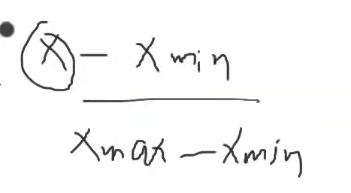

In [ ]:
# find the normalized IMDB Rating
# this is the example of the split , apply then and combine
def normalized_rating(group):
    group['normalized_rating']=group['IMDB_Rating'] - group['IMDB_Rating'].min()/(group['IMDB_Rating'].max()-group['IMDB_Rating'].min())
    return group
genre.apply(normalized_rating)

C:\Users\mnoma\AppData\Local\Temp\ipykernel_6528\2351436500.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  group['normalized_rating']=group['IMDB_Rating'] - group['IMDB_Rating'].min()/(group['IMDB_Rating'].max()-group['IMDB_Rating'].min())


MovieID                 Title  ReleaseYear          Director  \
Genre                                                                          
Action      4     M0003       The Frozen Path         2010  Ayesha Rodriguez   
            23    M0045  The Forgotten Signal         2026           Wei Lee   
            47    M0013         The Last Tide         2018      Robert Malik   
            51    M0095  The Forgotten Legacy         2025    Michael Farooq   
            53    M0120      The Hidden Storm         2001        Anna Ahmed   
...                 ...                   ...          ...               ...   
documentary 144   M0002   The Distant Promise         2010         Wei Ahmed   
sci-fi      147   M0081       The Final Storm         2022       James Malik   
thriller    27    M0075         The Lost City         2006         Anna Chen   
            98    M0009      The Final Signal         2019         Mina Chen   
            138   M0009      The Final Signal         2019         Mina Chen   

                Language  Duration_min  IMDB_Rating  Votes  \
Genre                                                        
Action      4     Korean           114          7.2  21717   
            23    KOREAN           114          5.4  59450   
            47   Spanish           127          6.0  88922   
            51   English           111          9.2  19167   
            53      Urdu           110          NaN  18041   
...                  ...           ...          ...    ...   
documentary 144   Korean           120          6.4   2639   
sci-fi      147  Punjabi           112          6.8  28678   
thriller    27     HINDI           119          6.9   4069   
            98      Urdu           119          7.3   3723   
            138     Urdu           119          7.3   3723   

                 BoxOffice_Million_USD  normalized_rating  
Genre                                                      
Action      4                     61.0           5.778947  
            23                     8.4           3.978947  
            47                    23.7           4.578947  
            51                    13.1           7.778947  
            53                    33.9                NaN  
...                                ...                ...  
documentary 144                    NaN           3.876190  
sci-fi      147                    8.5               -inf  
thriller    27                    23.4         -10.350000  
            98                    12.2          -9.950000  
            138                   12.2          -9.950000  

[153 rows x 10 columns]

In [ ]:
# groupby on the mutiple columns
dual=movies.groupby(['Director','Language'])
dual

In [20]:
dual.size()

Director       Language
Ahmed Ahmed    Korean      1
Ahmed Chen     Hindi       1
               Korean      1
Ahmed Garcia   Hindi       2
               URDU        1
                          ..
Wei Lee        KOREAN      1
               Punjabi     1
Wei Rodriguez  Spanish     2
               Urdu        1
Wei Smith      Urdu        1
Length: 137, dtype: int64

In [21]:
dual.get_group(('Ahmed Ahmed','Korean'))

,MovieID,Title,Genre,ReleaseYear,Director,Language,Duration_min,IMDB_Rating,Votes,BoxOffice_Million_USD
128,M0128,The Frozen Legacy,Drama,2025,Ahmed Ahmed,Korean,127,7.1,12056,72.0


In [27]:
dual['Duration_min'].agg(['max','min','mean']).head(10)

max  min   mean
Director        Language                 
Ahmed Ahmed     Korean    127  127  127.0
Ahmed Chen      Hindi     118  118  118.0
                Korean    103  103  103.0
Ahmed Garcia    Hindi     128  110  119.0
                URDU      121  121  121.0
Ahmed Johnson   Spanish   129  129  129.0
Ahmed Khan      Spanish   126  126  126.0
Ahmed Lee       Hindi     124  124  124.0
Ahmed Rodriguez Hindi     135  135  135.0
Anna Ahmed      Urdu      110  110  110.0

In [29]:
psl_data=pd.read_csv('psl_deliveries.csv')
psl_data

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1312025,1,Peshawar Zalmi,Karachi Kings,1,1,Sherfane Rutherford,Mohammad Haris,Usman Khan,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
1,1312025,1,Peshawar Zalmi,Karachi Kings,1,2,Sherfane Rutherford,Mohammad Haris,Usman Khan,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
2,1312025,1,Peshawar Zalmi,Karachi Kings,1,3,Sherfane Rutherford,Mohammad Haris,Usman Khan,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
3,1312025,1,Peshawar Zalmi,Karachi Kings,1,4,Sherfane Rutherford,Mohammad Haris,Usman Khan,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
4,1312025,1,Peshawar Zalmi,Karachi Kings,1,5,Mohammad Haris,Sherfane Rutherford,Usman Khan,0,...,0,0,0,0,3,0,3,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44312,1312084,2,Peshawar Zalmi,Lahore Qalandars,20,4,Aamer Jamal,Wahab Riaz,David Wiese,0,...,0,0,0,0,0,1,1,NaN,NaN,NaN
44313,1312084,2,Peshawar Zalmi,Lahore Qalandars,20,5,Aamer Jamal,Wahab Riaz,David Wiese,0,...,0,0,1,0,0,1,1,NaN,NaN,NaN
44314,1312084,2,Peshawar Zalmi,Lahore Qalandars,20,6,Aamer Jamal,Wahab Riaz,David Wiese,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
44315,1312084,2,Peshawar Zalmi,Lahore Qalandars,20,7,Aamer Jamal,Wahab Riaz,David Wiese,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [31]:
# find out the top 10 batsman on the basis of runs
psl_data.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

batsman
Sameen Gul            2174
Naseem Shah           1940
Iftikhar Ahmed        1938
Babar Azam            1767
Usman Khan            1607
Shadab Khan           1324
Tom Kohler-Cadmore    1080
Tayyab Tahir          1038
Rovman Powell         1019
Agha Salman           1015
Name: batsman_runs, dtype: int64

In [43]:
# find the total number of sixes by every player in the psl matches
six=psl_data[psl_data['batsman_runs']==6]
six.groupby('batsman')['batsman'].value_counts(ascending=False).head(1)

batsman
Aamer Jamal    44
Name: count, dtype: int64

In [44]:
# can also br done viva this
six=psl_data[psl_data['batsman_runs']==6]
six.groupby('batsman')['batsman'].count().sort_values(ascending=False).index[0]

'Babar Azam'

In [48]:
# find bastman with most no of 4 and 6 in the last 5 overs
temp_df=psl_data[psl_data['over']>15]
temp_df=temp_df[(temp_df['batsman_runs']==4) | (temp_df['batsman_runs']==6)]
temp_df.groupby('batsman')['batsman'].count().sort_values(ascending=False)

batsman
Sameen Gul         71
Iftikhar Ahmed     66
Babar Azam         65
Naseem Shah        58
Usman Khan         48
                   ..
Mohammad Nawaz     13
David Willey       12
Xavier Bartlett    10
Kamran Ghulam       9
David Wiese         8
Name: batsman, Length: 61, dtype: int64

In [53]:
# find Babar azam record against all teams
temp_info=psl_data[psl_data['batsman']=='Babar Azam']
temp_info.groupby('bowling_team')['batsman_runs'].sum().reset_index()

,bowling_team,batsman_runs
0,Islamabad United,247
1,Karachi Kings,158
2,Lahore Qalandars,254
3,Multan Sultans,265
4,Peshawar Zalmi,214
5,Quetta Gladiators,629


In [58]:
# create a function that can return score of any batsman
temp_data=psl_data[psl_data['batsman']=='Babar Azam']
temp_data.groupby('match_id')['batsman_runs'].sum().sort_values(ascending=False).head(1).values[0]


np.int64(112)

In [59]:
def highest_ones(batsman):
    temp_data=psl_data[psl_data['batsman']==batsman]
    return temp_data.groupby('match_id')['batsman_runs'].sum().sort_values(ascending=False).head(1).values[0]

In [61]:
print(highest_ones('Babar Azam'))

112
